<a href="https://colab.research.google.com/github/nika-chu/THESIS-2/blob/main/TEST_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENVIRONMENT SETUP**

---



In [1]:
!pip install torch torchvision timm pycocotools roboflow scikit-learn seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.9 MB/s eta 0:00:00


**Values shall be change per Experiment Run**



---





In [2]:
# EXPERIMENT 1:

Experiment_Name      = "Exp1_original_threshold05"
Confidence_Threshold = 0.5
DEIT_Var             = 'deit_small_patch16_224'
DATASET_Ver          = 1
EPOCHS_DEIT          = 30
EPOCHS_RCNN          = 20

print(f"Experiment  : {Experiment_Name}")
print(f"Threshold   : {Confidence_Threshold}")
print(f"DeiT model  : {DEIT_Var}")
print(f"Dataset ver : {DATASET_Ver}")
print(f"DeiT epochs : {EPOCHS_DEIT}")
print(f"RCNN epochs : {EPOCHS_RCNN}")

Experiment  : Exp1_original_threshold05
Threshold   : 0.5
DeiT model  : deit_small_patch16_224
Dataset ver : 1
DeiT epochs : 30
RCNN epochs : 20


In [3]:
import os
import json
import csv
import torch
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

from PIL import Image
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("All imports successful")

All imports successful


In [4]:
import os

# Download dataset
!curl -L "https://app.roboflow.com/ds/QhHvAu48hn?key=HqVDIAHSJv" \
  > roboflow.zip

# Unzip into a specific folder
!unzip roboflow.zip -d /content/rhizome_dataset

# Remove zip
!rm roboflow.zip

print("Download complete!")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   925  100   925    0     0   2501      0 --:--:-- --:--:-- --:--:--  2500
100  115M  100  115M    0     0  39.0M      0  0:00:02  0:00:02 --:--:-- 59.4M
Archive:  roboflow.zip
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00207_JPG.rf.qvTTnxepNiDjzNb9TxOx.JPG  
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00303_JPG.rf.6NLxQghMSBkbGVNAk4S7.JPG  
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00208_JPG.rf.t6VKRHXIkzrpq8SZ10qQ.JPG  
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00313_JPG.rf.3F26iGP6rkSJBYed97h8.JPG  
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00090_JPG.rf.65aIf8s1TEOR3VHNwx96.JPG  
 extracting: /content/rhizome_dataset/train/Rhizome Healthy Root00310_JPG.rf.6ZEHT0RdEnw6kOpa5ltX.JPG  
 extracting: /content/rhizome_dataset

In [5]:
import os
import json
import shutil
import random

random.seed(42)

SRC_DIR  = '/content/rhizome_dataset/train'
DST_ROOT = '/content/rhizome_dataset_v3'

# Load existing annotations
with open(os.path.join(SRC_DIR, '_annotations.coco.json')) as f:
    coco = json.load(f)

# Shuffle images
images = coco['images'].copy()
random.shuffle(images)

# Split counts
total   = len(images)
n_train = int(total * 0.70)
n_valid = int(total * 0.15)

train_imgs = images[:n_train]
valid_imgs = images[n_train:n_train + n_valid]
test_imgs  = images[n_train + n_valid:]

print(f"Total : {total}")
print(f"Train : {len(train_imgs)}")
print(f"Valid : {len(valid_imgs)}")
print(f"Test  : {len(test_imgs)}")

# Build annotation lookup
ann_map = {}
for ann in coco['annotations']:
    img_id = ann['image_id']
    if img_id not in ann_map:
        ann_map[img_id] = []
    ann_map[img_id].append(ann)

categories = coco['categories']

def save_split(split_name, split_imgs):
    split_dir = os.path.join(DST_ROOT, split_name)
    os.makedirs(split_dir, exist_ok=True)

    split_anns = []
    for img in split_imgs:
        src = os.path.join(SRC_DIR, img['file_name'])
        dst = os.path.join(split_dir, img['file_name'])
        if os.path.exists(src):
            shutil.copy(src, dst)
        img_anns = ann_map.get(img['id'], [])
        split_anns.extend(img_anns)

    coco_split = {
        'images':      split_imgs,
        'annotations': split_anns,
        'categories':  categories
    }
    ann_file = os.path.join(split_dir, '_annotations.coco.json')
    with open(ann_file, 'w') as f:
        json.dump(coco_split, f)

    print(f"  {split_name}/ → {len(split_imgs)} images, "
          f"{len(split_anns)} annotations")

print("\nCreating splits...")
save_split('train', train_imgs)
save_split('valid', valid_imgs)
save_split('test',  test_imgs)
print("\nDone!")

Total : 463
Train : 324
Valid : 69
Test  : 70

Creating splits...
  train/ → 324 images, 331 annotations
  valid/ → 69 images, 75 annotations
  test/ → 70 images, 72 annotations

Done!


In [6]:
DATASET_PATH = '/content/rhizome_dataset_v3'

TRAIN_IMG_DIR = os.path.join(DATASET_PATH, "train")
VALID_IMG_DIR = os.path.join(DATASET_PATH, "valid")
TEST_IMG_DIR  = os.path.join(DATASET_PATH, "test")

TRAIN_ANN = os.path.join(DATASET_PATH, "train", "_annotations.coco.json")
VALID_ANN = os.path.join(DATASET_PATH, "valid", "_annotations.coco.json")
TEST_ANN  = os.path.join(DATASET_PATH, "test",  "_annotations.coco.json")

for split, img_dir, ann in [
    ("Train", TRAIN_IMG_DIR, TRAIN_ANN),
    ("Valid", VALID_IMG_DIR, VALID_ANN),
    ("Test",  TEST_IMG_DIR,  TEST_ANN)
]:
    imgs = [f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    ann_ok = "✓" if os.path.exists(ann) else "✗"
    print(f"{split:6s} → {len(imgs):4d} images | "
          f"annotation {ann_ok}")

Train  →  324 images | annotation ✓
Valid  →   69 images | annotation ✓
Test   →   70 images | annotation ✓


In [7]:
with open(TRAIN_ANN) as f:
    coco = json.load(f)

print(f"Training images     : {len(coco['images'])}")
print(f"Training annotations: {len(coco['annotations'])}")
print(f"Classes             : {[c['name'] for c in coco['categories']]}")
print(f"Category IDs        : {[c['id']   for c in coco['categories']]}")

Training images     : 324
Training annotations: 331
Classes             : ['infected-healthy-xel3irtliobq3cnryksp', 'healthy', 'infected']
Category IDs        : [0, 1, 2]


In [8]:
class RhizomeClassificationDataset(Dataset):
    def __init__(self, ann_file, img_dir, transform=None):
        with open(ann_file) as f:
            coco = json.load(f)

        self.img_dir   = img_dir
        self.transform = transform

        self.categories = {c['id']: c['name'] for c in coco['categories']}
        print(f"Categories: {self.categories}")

        # Map image_id to category_id
        ann_map = {}
        for ann in coco['annotations']:
            img_id = ann['image_id']
            ann_map[img_id] = ann['category_id']

        # Build samples list
        self.samples = []
        for img in coco['images']:
            img_id   = img['id']
            filename = img['file_name']
            cat_id   = ann_map.get(img_id, None)
            if cat_id is None:
                continue
            # 1 = infected, 0 = healthy
            label = 1 if 'infected' in self.categories.get(
                         cat_id, '').lower() else 0
            self.samples.append((filename, label))

        print(f"Total samples: {len(self.samples)}")
        infected = sum(1 for _, l in self.samples if l == 1)
        healthy  = sum(1 for _, l in self.samples if l == 0)
        print(f"  Infected : {infected}")
        print(f"  Healthy  : {healthy}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img_path = os.path.join(self.img_dir, filename)
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_cls = RhizomeClassificationDataset(
    TRAIN_ANN, TRAIN_IMG_DIR, train_transform)
valid_cls = RhizomeClassificationDataset(
    VALID_ANN, VALID_IMG_DIR, val_transform)
test_cls  = RhizomeClassificationDataset(
    TEST_ANN,  TEST_IMG_DIR,  val_transform)

train_cls_loader = DataLoader(
    train_cls, batch_size=16, shuffle=True,  num_workers=2)
valid_cls_loader = DataLoader(
    valid_cls, batch_size=16, shuffle=False, num_workers=2)
test_cls_loader  = DataLoader(
    test_cls,  batch_size=16, shuffle=False, num_workers=2)

print(f"Train : {len(train_cls)} images")
print(f"Valid : {len(valid_cls)} images")
print(f"Test  : {len(test_cls)}  images")

Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Total samples: 323
  Infected : 124
  Healthy  : 199
Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Total samples: 69
  Infected : 28
  Healthy  : 41
Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Total samples: 70
  Infected : 29
  Healthy  : 41
Train : 323 images
Valid : 69 images
Test  : 70  images


In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_deit_model(variant, num_classes=2):
    model = timm.create_model(
        variant,
        pretrained=True,
        num_classes=num_classes
    )
    return model

deit_model = build_deit_model(DEIT_Var, num_classes=2).to(DEVICE)
total_params = sum(p.numel() for p in deit_model.parameters())
print(f"DeiT variant : {DEIT_Var}")
print(f"Parameters   : {total_params:,}")
print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

DeiT variant : deit_small_patch16_224
Parameters   : 21,666,434
Model loaded successfully


In [11]:
def train_deit(model, train_loader, valid_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total * 100
        scheduler.step()

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Loss: {avg_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/content/deit_best.pth')
            print(f"  → Best model saved ({val_acc:.2f}%)")

    print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")
    return history

deit_history = train_deit(
    deit_model, train_cls_loader, valid_cls_loader, EPOCHS_DEIT)

Epoch [01/30] Loss: 0.2008 | Val Acc: 97.10%
  → Best model saved (97.10%)
Epoch [02/30] Loss: 0.0232 | Val Acc: 95.65%
Epoch [03/30] Loss: 0.0135 | Val Acc: 100.00%
  → Best model saved (100.00%)
Epoch [04/30] Loss: 0.0023 | Val Acc: 97.10%
Epoch [05/30] Loss: 0.0009 | Val Acc: 100.00%
Epoch [06/30] Loss: 0.0005 | Val Acc: 100.00%
Epoch [07/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [08/30] Loss: 0.0003 | Val Acc: 100.00%
Epoch [09/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [10/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [11/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [12/30] Loss: 0.0004 | Val Acc: 100.00%
Epoch [13/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [14/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [15/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [16/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [17/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [18/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [19/30] Loss: 0.0002 | Val Acc: 100.00%
Epoch [20/30] Loss: 0.0001 | Val Acc: 100.00%
Epoch [21/30] Loss: 0.

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        41
    Infected       1.00      1.00      1.00        29

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



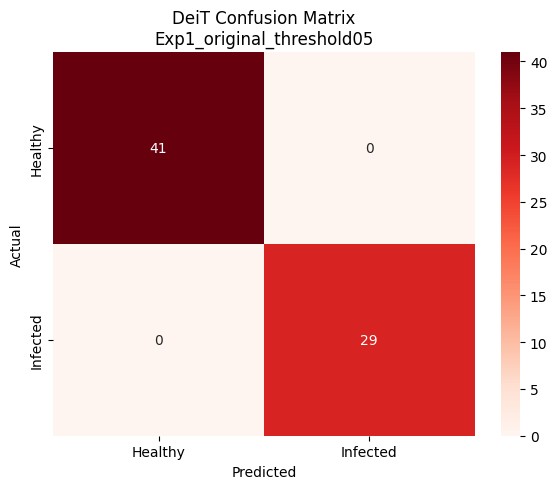

In [12]:
def evaluate_deit(model, test_loader):
    model.load_state_dict(torch.load('/content/deit_best.pth'))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Determine unique labels actually present in the ground truth
    unique_labels_in_data = np.unique(all_labels).tolist()

    # Define the mapping from internal label (0 or 1) to human-readable name
    label_to_name_map = {0: 'Healthy', 1: 'Infected'}

    # Filter target names to match the unique labels present in the data
    filtered_target_names = [label_to_name_map[label] for label in unique_labels_in_data]

    print("Classification Report:")
    print(classification_report(
        all_labels, all_preds,
        labels=unique_labels_in_data, # Pass only labels found in all_labels
        target_names=filtered_target_names, # Use filtered target names
        zero_division=0 # Set to 0 to avoid warnings/errors for classes not present
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels_in_data)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=filtered_target_names,
                yticklabels=filtered_target_names)
    plt.title(f'DeiT Confusion Matrix\n{Experiment_Name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'/content/deit_confusion_{Experiment_Name}.png')
    plt.show()

    return all_labels, all_preds

deit_labels, deit_preds = evaluate_deit(deit_model, test_cls_loader)

In [13]:
def compute_metrics(all_labels, all_preds, model_name):
    acc  = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(
        all_labels, all_preds, average='weighted') * 100
    rec  = recall_score(
        all_labels, all_preds, average='weighted') * 100
    f1   = f1_score(
        all_labels, all_preds, average='weighted') * 100

    print(f"\n{'='*45}")
    print(f"  {model_name} — {Experiment_Name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {prec:.2f}%")
    print(f"  Recall    : {rec:.2f}%")
    print(f"  F1-Score  : {f1:.2f}%")
    print(f"{'='*45}")

    return acc, prec, rec, f1

deit_acc, deit_prec, deit_rec, deit_f1 = compute_metrics(
    deit_labels, deit_preds, "DeiT-Small")


  DeiT-Small — Exp1_original_threshold05
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%


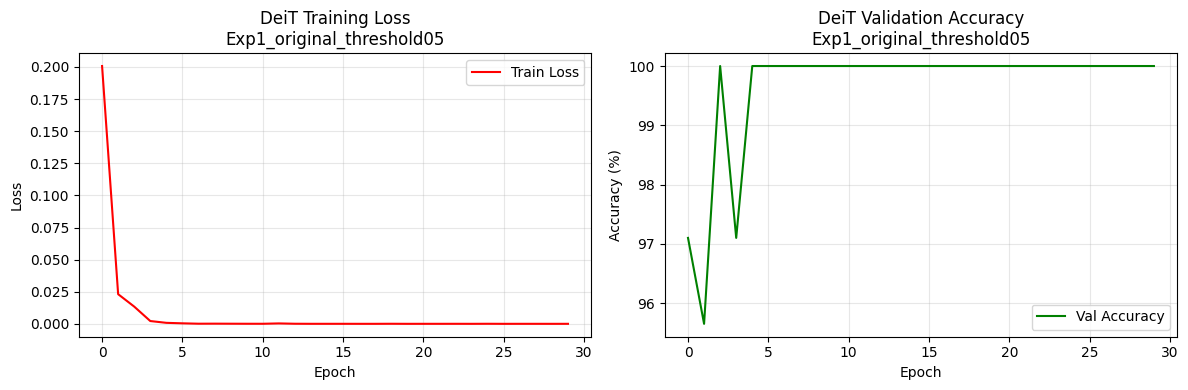

In [14]:
def plot_deit_history(history, experiment_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'],
             color='red', label='Train Loss')
    ax1.set_title(
        f'DeiT Training Loss\n{experiment_name}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['val_acc'],
             color='green', label='Val Accuracy')
    ax2.set_title(
        f'DeiT Validation Accuracy\n{experiment_name}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f'/content/deit_history_{Experiment_Name}.png')
    plt.show()

plot_deit_history(deit_history, Experiment_Name)

In [21]:
def log_results(experiment_name, model_name, acc,
                prec, rec, f1, threshold,
                deit_variant, dataset_version):

    os.makedirs(
        '/content/drive/MyDrive/THESIS_MODELS',
        exist_ok=True)
    log_file = ('/content/drive/MyDrive/'
                'THESIS_MODELS/experiment_log.csv')
    file_exists = os.path.exists(log_file)

    with open(log_file, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow([
                'timestamp', 'experiment', 'model',
                'deit_variant', 'dataset_version',
                'threshold', 'accuracy',
                'precision', 'recall', 'f1'
            ])
        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M"),
            experiment_name, model_name,
            deit_variant, dataset_version,
            threshold,
            f"{acc:.2f}", f"{prec:.2f}",
            f"{rec:.2f}", f"{f1:.2f}"
        ])

    print(f"Logged → {experiment_name} | "
          f"{model_name} | Acc: {acc:.2f}%")

log_results(
    Experiment_Name, "DeiT",
    deit_acc, deit_prec, deit_rec, deit_f1,
    Confidence_Threshold, DEIT_Var,
    DATASET_Ver
)

Logged → Exp1_original_threshold05 | DeiT | Acc: 100.00%


In [31]:
class RhizomeDetectionDataset(Dataset):
    def __init__(self, ann_file, img_dir):
        with open(ann_file) as f:
            coco = json.load(f)

        self.img_dir    = img_dir
        self.images     = coco['images']
        self.categories = {
            c['id']: c['name']
            for c in coco['categories']}

        self.ann_map = {}
        for ann in coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.ann_map:
                self.ann_map[img_id] = []
            self.ann_map[img_id].append(ann)

        print(f"Detection dataset: {len(self.images)} images")
        print(f"Categories: {self.categories}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id   = img_info['id']
        img_path = os.path.join(
            self.img_dir, img_info['file_name'])
        image    = Image.open(img_path).convert('RGB')

        anns = self.ann_map.get(img_id, [])
        boxes, labels = [], []

        for ann in anns:
            x, y, w, h = ann['bbox']
            # Ensure bbox coordinates are numeric and convert to int by first casting to float
            x, y, w, h = int(float(x)), int(float(y)), int(float(w)), int(float(h))
            if w > 0 and h > 0:
                boxes.append([x, y, x + w, y + h])
                labels.append(ann['category_id'])

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4),
                                 dtype=torch.float32)
            labels = torch.zeros((0,),
                                 dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,
                                  dtype=torch.float32)
            labels = torch.tensor(labels,
                                  dtype=torch.int64)

        target = {
            'boxes':    boxes,
            'labels':   labels,
            'image_id': torch.tensor([img_id])
        }

        image = transforms.ToTensor()(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

In [32]:
train_det = RhizomeDetectionDataset(
    TRAIN_ANN, TRAIN_IMG_DIR)
valid_det = RhizomeDetectionDataset(
    VALID_ANN, VALID_IMG_DIR)
test_det  = RhizomeDetectionDataset(
    TEST_ANN,  TEST_IMG_DIR)

train_det_loader = DataLoader(
    train_det, batch_size=4, shuffle=True,
    collate_fn=collate_fn, num_workers=2)
valid_det_loader = DataLoader(
    valid_det, batch_size=4, shuffle=False,
    collate_fn=collate_fn, num_workers=2)
test_det_loader  = DataLoader(
    test_det,  batch_size=4, shuffle=False,
    collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_det)} | "
      f"Valid : {len(valid_det)} | "
      f"Test  : {len(test_det)}")

Detection dataset: 324 images
Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Detection dataset: 69 images
Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Detection dataset: 70 images
Categories: {0: 'infected-healthy-xel3irtliobq3cnryksp', 1: 'healthy', 2: 'infected'}
Train : 324 | Valid : 69 | Test  : 70


In [33]:
def build_faster_rcnn(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = (model.roi_heads
                       .box_predictor
                       .cls_score.in_features)
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features, num_classes)
    return model

with open(TRAIN_ANN) as f:
    coco_info = json.load(f)

NUM_CLASSES = len(coco_info['categories']) + 1
print(f"Classes (+ background): {NUM_CLASSES}")

rcnn_model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)
print("Faster R-CNN loaded successfully")

Classes (+ background): 4


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Faster R-CNN loaded successfully


In [34]:
def train_faster_rcnn(model, train_loader,
                      valid_loader, epochs):
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.005, momentum=0.9, weight_decay=0.0005)
    scheduler = StepLR(
        optimizer, step_size=7, gamma=0.1)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, targets in train_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [
                {k: v.to(DEVICE) for k, v in t.items()}
                for t in targets]

            loss_dict = model(images, targets)
            losses    = sum(
                loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            running_loss += losses.item()

        avg_train = running_loss / len(train_loader)

        model.train()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in valid_loader:
                images  = [img.to(DEVICE)
                           for img in images]
                targets = [
                    {k: v.to(DEVICE)
                     for k, v in t.items()}
                    for t in targets]
                loss_dict = model(images, targets)
                val_loss += sum(
                    loss for loss in
                    loss_dict.values()).item()

        avg_val = val_loss / len(valid_loader)
        scheduler.step()

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(
                model.state_dict(),
                '/content/faster_rcnn_best.pth')
            print(f"  → Best saved ({avg_val:.4f})")

    print(f"\nBest Val Loss: {best_val_loss:.4f}")
    return history

rcnn_history = train_faster_rcnn(
    rcnn_model, train_det_loader,
    valid_det_loader, EPOCHS_RCNN)

Epoch [01/20] Train Loss: 0.1802 | Val Loss: 0.1439
  → Best saved (0.1439)
Epoch [02/20] Train Loss: 0.0928 | Val Loss: 0.1124
  → Best saved (0.1124)
Epoch [03/20] Train Loss: 0.0727 | Val Loss: 0.1128
Epoch [04/20] Train Loss: 0.0653 | Val Loss: 0.1037
  → Best saved (0.1037)
Epoch [05/20] Train Loss: 0.0564 | Val Loss: 0.1028
  → Best saved (0.1028)
Epoch [06/20] Train Loss: 0.0518 | Val Loss: 0.1036
Epoch [07/20] Train Loss: 0.0451 | Val Loss: 0.1011
  → Best saved (0.1011)
Epoch [08/20] Train Loss: 0.0350 | Val Loss: 0.1010
  → Best saved (0.1010)
Epoch [09/20] Train Loss: 0.0324 | Val Loss: 0.0988
  → Best saved (0.0988)
Epoch [10/20] Train Loss: 0.0312 | Val Loss: 0.1017
Epoch [11/20] Train Loss: 0.0307 | Val Loss: 0.1022
Epoch [12/20] Train Loss: 0.0302 | Val Loss: 0.1024
Epoch [13/20] Train Loss: 0.0291 | Val Loss: 0.1029
Epoch [14/20] Train Loss: 0.0284 | Val Loss: 0.1033
Epoch [15/20] Train Loss: 0.0275 | Val Loss: 0.1013
Epoch [16/20] Train Loss: 0.0274 | Val Loss: 0.1029


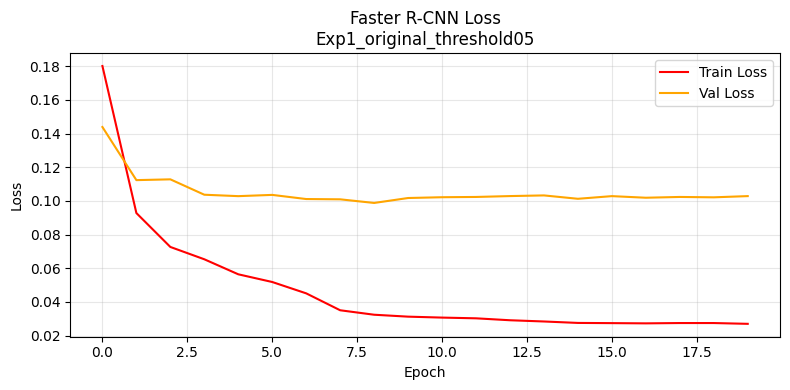

In [36]:
def plot_rcnn_history(history, experiment_name):
    plt.figure(figsize=(8, 4))
    plt.plot(history['train_loss'],
             label='Train Loss', color='red')
    plt.plot(history['val_loss'],
             label='Val Loss',   color='orange')
    plt.title(
        f'Faster R-CNN Loss\n{experiment_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f'/content/rcnn_history_{Experiment_Name}.png')
    plt.show()

plot_rcnn_history(rcnn_history, Experiment_Name)